last code

In [1]:
import pandas as pd
import seaborn as sns, matplotlib as plt
import scipy.stats as stats
import ast

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)
df['tags'] = df['tags'].apply(ast.literal_eval)
df.head()

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0
1,8,High pass,[Accurate],Abdullah Ibrahim Otayf,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,4.487814,High pass,258612106,35,53,75.0,19.0
2,1,Air duel,"[Won, Accurate]",Ilya Kutepov,"Russia - Saudi Arabia, 5 - 0",Duel,Russia,1H,5.937411,Air duel,258612077,25,81,37.0,83.0
3,1,Air duel,"[Lost, Not accurate]",Yasir Gharsan Al Shahrani,"Russia - Saudi Arabia, 5 - 0",Duel,Saudi Arabia,1H,6.406961,Air duel,258612112,75,19,63.0,17.0
4,8,Simple pass,[Accurate],Salman Mohammed Al Faraj,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,8.562167,Simple pass,258612110,63,17,71.0,15.0


In [2]:
x_max = 120
y_max = 75

df["x1"] = (df["x1"] / 100) * x_max
df["x2"] = (df["x2"] / 100) * x_max
df["y1"] = (df["y1"] / 100) * y_max
df["y2"] = (df["y2"] / 100) * y_max

In [3]:
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,60.0,37.5,42.0,39.75


In [4]:
df["shot"] = (df['eventName'] == "Shot").astype(int)
df.loc[df["shot"] == 1, ["x2", "y2"]]

,x2,y2
117,120.0,75.0
154,0.0,0.0
197,0.0,0.0
232,0.0,0.0
372,120.0,75.0
...,...,...
101371,120.0,75.0
101457,120.0,75.0
101493,120.0,75.0
101620,0.0,0.0


In [5]:
df.loc[[117,154,197]]

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,shot
117,10,Shot,"[Right foot, Blocked, Not accurate]",Yasir Gharsan Al Shahrani,"Russia - Saudi Arabia, 5 - 0",Shot,Saudi Arabia,1H,327.142941,Shot,258612248,104.4,20.25,120.0,75.0,1
154,10,Shot,"[Right foot, Blocked, Not accurate]",Alexandr Samedov,"Russia - Saudi Arabia, 5 - 0",Shot,Russia,1H,407.123899,Shot,258612244,108.0,51.75,0.0,0.0,1
197,10,Shot,"[Left foot, Blocked, Not accurate]",Yuri Zhirkov,"Russia - Saudi Arabia, 5 - 0",Shot,Russia,1H,526.276996,Shot,258612307,103.2,22.50,0.0,0.0,1


In [7]:
box_h = 40
box_w = 18

box_ymin = (y_max / 2) - (box_h / 2)
box_ymax = (y_max / 2) + (box_h / 2)
box_xmax = x_max
box_xmin = box_xmax - box_w

df["g_event"] = (
    (box_ymin < df["y1"]) & (df["y1"] < box_ymax) & 
    (box_xmin < df["x1"]) & (df["x1"] < box_xmax)
    ).astype(int)
df["g_event"].sum()

np.int64(3760)

In [8]:
g_df = df.groupby(["matchId", "teamId"]).agg(
    shots = ("shot", "sum"),
    g_events = ("g_event", "sum")
).reset_index()
g_df

,matchId,teamId,shots,g_events
0,"Argentina - Croatia, 0 - 3",Argentina,10,28
1,"Argentina - Croatia, 0 - 3",Croatia,13,23
2,"Argentina - Iceland, 1 - 1",Argentina,22,51
3,"Argentina - Iceland, 1 - 1",Iceland,8,24
4,"Australia - Peru, 0 - 2",Australia,11,46
...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,14
124,"Uruguay - Russia, 3 - 0",Russia,3,14
125,"Uruguay - Russia, 3 - 0",Uruguay,12,23
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,16


[Text(0.5, 1.0, 'Correlation between Golden Events and Shots'),
 Text(0.5, 0, 'Golden Events'),
 Text(0, 0.5, 'Shots')]

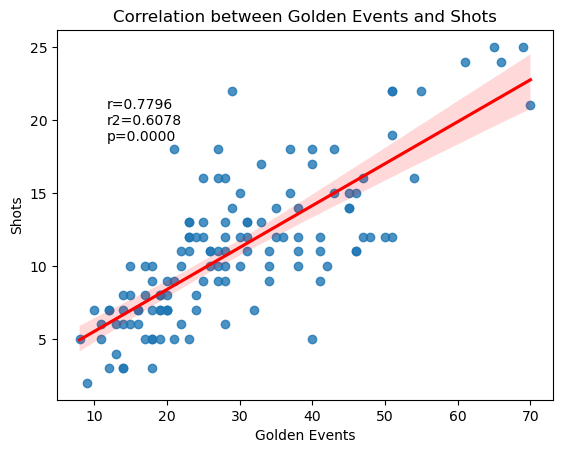

In [13]:
r, p = stats.pearsonr(g_df["g_events"], g_df["shots"])
r2 = r**2
text = f"""r={r:.4f}
r2={r2:.4f}
p={p:.4f}"""
reg = sns.regplot(data=g_df, x="g_events", y="shots", line_kws={"color": "red", "label": "Line of Best Fit"})
reg.text(x = 0.1, y = 0.7, s=text, transform=reg.transAxes)
reg.set(title="Correlation between Golden Events and Shots",
              xlabel="Golden Events",
              ylabel="Shots")
